In [92]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from matplotlib.animation import FuncAnimation
import time
from IPython.display import HTML

In [93]:
@njit(fastmath=True, cache=True)
def inicjalizacja(N):  #return np.random.choice([-1, 1], size=(N, N))
    siatka = np.ones((N, N), dtype=np.int8)
    for i in range(N):
        for j in range(N):
            if np.random.rand() < 0.5:
                siatka[i, j] = -1
    return siatka

In [94]:
@njit(fastmath=True, cache=True)
def oblicz_delta_E(siatka, x, y, N, J, B):
    
    s_i = siatka[x, y]
    
    gora = (x - 1) % N
    dol = (x + 1) % N
    lewo = (y - 1) % N
    prawo = (y + 1) % N
    
    suma_sasiadow = (
        siatka[gora, y] + siatka[dol, y] + siatka[x, lewo] + siatka[x, prawo] +
        siatka[gora, lewo] + siatka[gora, prawo] + siatka[dol, lewo] + siatka[dol, prawo]
    )
    
    return 2 * s_i * (J * suma_sasiadow + B)

@njit(fastmath=True, cache=True)
def oblicz_poczatkowa_energie(siatka, N, J, B):
    energia_oddzialywan = 0.0
    energia_pola = 0.0
    
    for x in range(N):
        for y in range(N):
            gora = (x - 1) % N
            dol = (x + 1) % N
            lewo = (y - 1) % N
            prawo = (y + 1) % N
            
            suma_sasiadow = (
                siatka[gora, y] + siatka[dol, y] + siatka[x, lewo] + siatka[x, prawo] +
                siatka[gora, lewo] + siatka[gora, prawo] + siatka[dol, lewo] + siatka[dol, prawo]
            )
            
            energia_oddzialywan += -J * siatka[x, y] * suma_sasiadow
            energia_pola += -B * siatka[x, y]
            
    return (energia_oddzialywan / 2) + energia_pola
@njit(fastmath=True, cache=True)
def oblicz_magnetyzacje(siatka, N):
    return np.sum(siatka) / (N**2)

In [95]:
@njit(fastmath=True, cache=True)
def wykonaj_makrokrok(siatka, N, J, beta, B, aktualna_energia):
    liczba_prob = N**2
    
    for _ in range(liczba_prob):
        x = np.random.randint(0, N)
        y = np.random.randint(0, N)
        
        delta_E = oblicz_delta_E(siatka, x, y, N, J, B)
        
        if delta_E < 0:
            siatka[x, y] *= -1
            aktualna_energia += delta_E
        else:
            prawdopodobienstwo = np.exp(-beta * delta_E)
            if np.random.rand() < prawdopodobienstwo:
                siatka[x, y] *= -1
                aktualna_energia += delta_E
                
    return siatka, aktualna_energia

In [96]:
@njit(fastmath=True, cache=True)
def uruchom_symulacje(N, J, beta, B, M):
    siatka = inicjalizacja(N)
    aktualna_energia = oblicz_poczatkowa_energie(siatka, N, J, B)
    
    historia_magnetyzacji = np.zeros(M, dtype=np.float64)
    historia_energii = np.zeros(M, dtype=np.float64)
    historia_siatki = np.zeros((M, N, N), dtype=np.int8) 
    
    for krok in range(M):
        siatka, aktualna_energia = wykonaj_makrokrok(siatka, N, J, beta, B, aktualna_energia)
        
        historia_magnetyzacji[krok] = oblicz_magnetyzacje(siatka, N)
        historia_energii[krok] = aktualna_energia
        historia_siatki[krok] = siatka
        
    return historia_siatki, historia_magnetyzacji, historia_energii

Czas wykonania: 0.0438 s


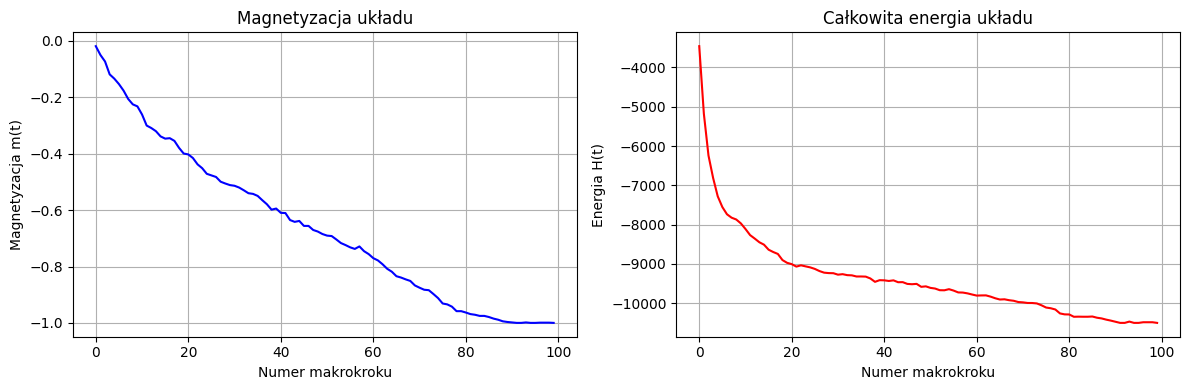

In [ ]:
N_val = 50       
J_val = 1.0      
beta_val = 0.5  
B_val = -0.2     
M_val = 100      

start_time = time.time()

hist_siatki, hist_mag, hist_en = uruchom_symulacje(N_val, J_val, beta_val, B_val, M_val)

czas_wykonania = time.time() - start_time
print(f"Czas wykonania: {czas_wykonania:.4f} s")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist_mag, color='blue')
ax1.set_title('Magnetyzacja układu')
ax1.set_xlabel('Numer makrokroku')
ax1.set_ylabel('Magnetyzacja m(t)')
ax1.grid(True)

ax2.plot(hist_en, color='red')
ax2.set_title('Całkowita energia układu')
ax2.set_xlabel('Numer makrokroku')
ax2.set_ylabel('Energia H(t)')
ax2.grid(True)

plt.tight_layout()
plt.show()

fig_anim, ax_anim = plt.subplots(figsize=(6,6))
ax_anim.set_title("Ewolucja modelu Isinga")
obraz = ax_anim.imshow(hist_siatki[0], cmap='binary', vmin=-1, vmax=1)

def aktualizuj_klatke(frame_num):
    obraz.set_data(hist_siatki[frame_num])
    return [obraz]

anim = FuncAnimation(fig_anim, aktualizuj_klatke, frames=M_val, interval=100, blit=True)
plt.close(fig_anim)



HTML(anim.to_jshtml())